True underlying line:
  y = 2.4000x + -0.3000

PART A: Linear Least Squares vs Cubic Polyfit
Linear LS equation:
  y = 2.201351x + -0.072085

Cubic polynomial equation:
  y = (1.9360)x^3 + (-2.0929)x^2 + (2.5461)x + (-0.0322)

Linear Least Squares
  MSE      = 0.303889
  R^2      = 0.575452

Cubic Polyfit
  MSE      = 0.298669
  R^2      = 0.582745

Better fit in Part A: Cubic Polyfit



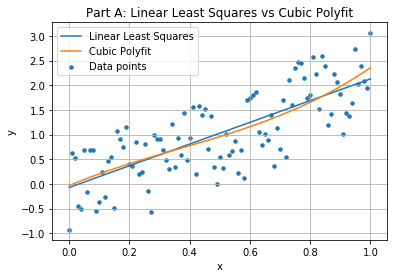

PART B: Polynomial Degree Sweep
Degree  1: MSE = 0.303889, R^2 = 0.575452
Degree  2: MSE = 0.300088, R^2 = 0.580762
Degree  3: MSE = 0.298669, R^2 = 0.582745
Degree  4: MSE = 0.293128, R^2 = 0.590486
Degree  5: MSE = 0.293116, R^2 = 0.590503
Degree  6: MSE = 0.284253, R^2 = 0.602884
Degree  7: MSE = 0.263548, R^2 = 0.631810
Degree  8: MSE = 0.261643, R^2 = 0.634471
Degree  9: MSE = 0.260900, R^2 = 0.635509
Degree 10: MSE = 0.255721, R^2 = 0.642745
Degree 11: MSE = 0.254694, R^2 = 0.644180
Degree 12: MSE = 0.246049, R^2 = 0.656258

Underfit example chosen: degree 1
Middle example chosen:   degree 3
Overfit example chosen:  degree 12



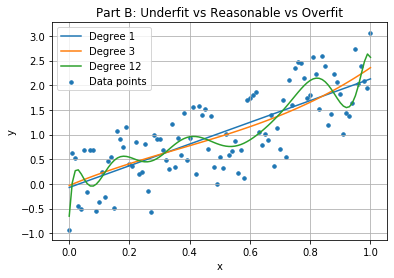

PART C: Vandermonde Polynomial Fit
Cubic Vandermonde polynomial equation:
  y = (1.9360)x^3 + (-2.0929)x^2 + (2.5461)x + (-0.0322)

Cubic Vandermonde Fit
  MSE      = 0.298669
  R^2      = 0.582745

Comparison with numpy.polyfit cubic:
  Vandermonde coeffs: [ 1.93597704 -2.09289588  2.546098   -0.03217313]
  Polyfit coeffs:     [ 1.93597704 -2.09289588  2.546098   -0.03217313]



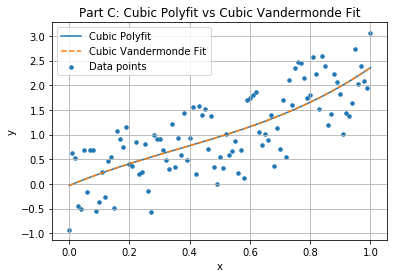

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def linear_least_squares(x, y):
    A = np.column_stack((x, np.ones_like(x)))
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    y_pred = m * x + b
    return m, b, y_pred

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def polyfit_model(x, y, degree):
    coeffs = np.polyfit(x, y, degree)
    y_pred = np.polyval(coeffs, x)
    return coeffs, y_pred

def vandermonde_fit(x, y, degree):
    V = np.vander(x, degree + 1)   
    coeffs = np.linalg.lstsq(V, y, rcond=None)[0]
    y_pred = V @ coeffs
    return coeffs, y_pred

def print_metrics(name, y_true, y_pred):
    current_mse = mse(y_true, y_pred)
    current_r2 = r_squared(y_true, y_pred)
    print(f"{name}")
    print(f"  MSE      = {current_mse:.6f}")
    print(f"  R^2      = {current_r2:.6f}")
    print()

def polynomial_string(coeffs):
    deg = len(coeffs) - 1
    pieces = []
    for i, c in enumerate(coeffs):
        power = deg - i
        if power > 1:
            pieces.append(f"({c:.4f})x^{power}")
        elif power == 1:
            pieces.append(f"({c:.4f})x")
        else:
            pieces.append(f"({c:.4f})")
    return " + ".join(pieces)

rng = np.random.default_rng(7)

x = np.arange(0, 1.01, 0.01)
m_true = 2.4
b_true = -0.3

error_mag = rng.random(len(x))
error_sign = rng.choice([-1.0, 1.0], size=len(x))
noise = error_sign * error_mag

y = m_true * x + b_true + noise

print("True underlying line:")
print(f"  y = {m_true:.4f}x + {b_true:.4f}")
print()

print("=========================================================")
print("PART A: Linear Least Squares vs Cubic Polyfit")
print("=========================================================")

m_ls, b_ls, y_ls = linear_least_squares(x, y)

deg_a = 3
coeffs_cubic, y_cubic = polyfit_model(x, y, deg_a)

mse_ls = mse(y, y_ls)
r2_ls = r_squared(y, y_ls)

mse_cubic = mse(y, y_cubic)
r2_cubic = r_squared(y, y_cubic)

print(f"Linear LS equation:")
print(f"  y = {m_ls:.6f}x + {b_ls:.6f}")
print()

print(f"Cubic polynomial equation:")
print(f"  y = {polynomial_string(coeffs_cubic)}")
print()

print_metrics("Linear Least Squares", y, y_ls)
print_metrics("Cubic Polyfit", y, y_cubic)

if mse_cubic < mse_ls and r2_cubic > r2_ls:
    better_a = "Cubic Polyfit"
elif mse_ls < mse_cubic and r2_ls > r2_cubic:
    better_a = "Linear Least Squares"
else:
    better_a = "Mixed result (one metric favors one fit, other metric may differ)"

print(f"Better fit in Part A: {better_a}")
print()

plt.figure()
plt.scatter(x, y, s=12, label="Data points")
plt.plot(x, y_ls, label="Linear Least Squares")
plt.plot(x, y_cubic, label="Cubic Polyfit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part A: Linear Least Squares vs Cubic Polyfit")
plt.grid(True)
plt.legend()
plt.show()

print("=========================================================")
print("PART B: Polynomial Degree Sweep")
print("=========================================================")

degrees = range(1, 13)

results = []

for d in degrees:
    coeffs_d, y_pred_d = polyfit_model(x, y, d)
    current_mse = mse(y, y_pred_d)
    current_r2 = r_squared(y, y_pred_d)
    results.append((d, current_mse, current_r2, coeffs_d, y_pred_d))
    print(f"Degree {d:2d}: MSE = {current_mse:.6f}, R^2 = {current_r2:.6f}")

print()

underfit_degree = 1
middle_degree = 3
overfit_degree = 12

coeffs_under, y_under = polyfit_model(x, y, underfit_degree)
coeffs_mid, y_mid = polyfit_model(x, y, middle_degree)
coeffs_over, y_over = polyfit_model(x, y, overfit_degree)

print(f"Underfit example chosen: degree {underfit_degree}")
print(f"Middle example chosen:   degree {middle_degree}")
print(f"Overfit example chosen:  degree {overfit_degree}")
print()

plt.figure()
plt.scatter(x, y, s=12, label="Data points")
plt.plot(x, y_under, label=f"Degree {underfit_degree}")
plt.plot(x, y_mid, label=f"Degree {middle_degree}")
plt.plot(x, y_over, label=f"Degree {overfit_degree}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part B: Underfit vs Reasonable vs Overfit")
plt.grid(True)
plt.legend()
plt.show()

print("=========================================================")
print("PART C: Vandermonde Polynomial Fit")
print("=========================================================")

vand_degree = 3

coeffs_vand, y_vand = vandermonde_fit(x, y, vand_degree)

print("Cubic Vandermonde polynomial equation:")
print(f"  y = {polynomial_string(coeffs_vand)}")
print()

print_metrics("Cubic Vandermonde Fit", y, y_vand)

print("Comparison with numpy.polyfit cubic:")
print(f"  Vandermonde coeffs: {coeffs_vand}")
print(f"  Polyfit coeffs:     {coeffs_cubic}")
print()

plt.figure()
plt.scatter(x, y, s=12, label="Data points")
plt.plot(x, y_cubic, label="Cubic Polyfit")
plt.plot(x, y_vand, linestyle="--", label="Cubic Vandermonde Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part C: Cubic Polyfit vs Cubic Vandermonde Fit")
plt.grid(True)
plt.legend()
plt.show()